In [25]:
from langgraph.graph import StateGraph , START , END 
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel , Field
from typing import TypedDict , Annotated
import operator

load_dotenv()


True

In [26]:
class Model_Schema(BaseModel):
    content:str = Field(description=f"review the content , of the essay.")
    Score:int = Field(description=f"rate the essay content out of ten and give a score .")

In [27]:
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [28]:
structured_model = model.with_structured_output(Model_Schema)

In [29]:
class State_Schema(TypedDict):
    essay : str
    Truth : str
    Grammer : str
    logical_correctness : str
    
    final_verdict : str
    individual_score:Annotated[list[int],operator.add]
    final_score:float


In [30]:
graph = StateGraph(State_Schema)

In [31]:
def Truth(state:State_Schema):
    prompt = f"review the essay based on the Truth present in it :{state['essay']}"
    res = structured_model.invoke(prompt)

    return {'Truth':res.content , 'individual_score':[res.Score]}


In [32]:
def Grammer(state:State_Schema):
    prompt = f"review the essay based on the Grammer present in it :{state['essay']}"
    res = structured_model.invoke(prompt)

    return {'Grammer':res.content , 'individual_score':[res.Score]}

In [33]:
def logical_correctness(state:State_Schema):
    prompt = f"review the essay based on the logical_correctness of it :{state['essay']}"
    res = structured_model.invoke(prompt)

    return {'logical_correctness':res.content , 'individual_score':[res.Score]}

In [45]:
def final_verdict(state:State_Schema):
    prompt = f"Declare a final verdict based on these reviews of the essay :{state['Grammer']} , {state['Truth']} and {state['logical_correctness']}"
    content = model.invoke(prompt)

    avg_score = sum(state['individual_score'])/len(state['individual_score'])

    return {'final_verdict':content.content , 'final_score':round(avg_score , 2)}

In [35]:
#add nodes
graph.add_node('Truth',Truth)
graph.add_node('Grammer',Grammer)
graph.add_node('logical_correctness',logical_correctness)
graph.add_node('final_verdict',final_verdict)

#add edges
graph.add_edge(START,'Truth')
graph.add_edge(START,'Grammer') 
graph.add_edge(START,'logical_correctness')

graph.add_edge('Truth','final_verdict')
graph.add_edge('Grammer','final_verdict')
graph.add_edge('logical_correctness','final_verdict')

graph.add_edge('final_verdict',END)

#compile Graph

Workflow = graph.compile()




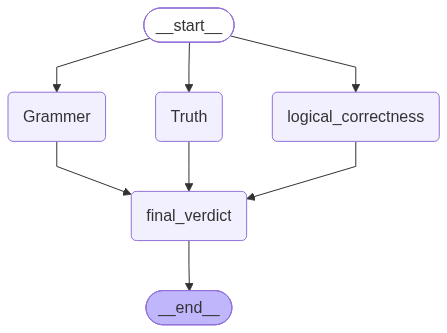

In [37]:
Workflow

In [46]:
intial_state = {
    'essay':'''India got independance in 1947 after long struggle but the story is not always told properly. Britishers was ruling India for almost 200 years and peoples was suffering from taxes and poverty. Many leaders like Gandi, Nehru and Bose fighted in different ways. Gandi used non violance, like Salt March, but some others wanted more fast action. The Quit India movement in 1942 was very importent because it show that Indians was not happy anymore.

During World War 2, Britain was weak and cannot control India properly. Indian soldiers also fight in war and they wanted freedom after. In 1946, navy mutiny happen and Britishers got scared. Finally they decide to leave India. On 15 August 1947, India become free country. Nehru gave speech “Tryst with Destiny” which is famous but many peoples dont know about it clearly.'''
}

res = Workflow.invoke(intial_state)



In [47]:

print(res['final_verdict'])
print(res['individual_score'])
print(res['final_score'])


content='The final verdict is that the essay is **historically accurate, logically structured, and comprehensive in its coverage of India\'s independence movement, but critically flawed in its execution due to extensive grammatical errors, spelling mistakes, and awkward phrasing that severely impede readability and overall academic quality.**\n\n**In summary:**\n\n*   **Strengths (Content & Structure):** The essay successfully provides an accurate, logical, and chronologically sound overview of India\'s independence movement. It correctly identifies key events (British rule, Salt March, Quit India Movement, WW2 impact, 1946 navy mutiny, 1947 independence) and prominent figures (Gandhi, Nehru, Bose), demonstrating a strong grasp of historical facts and their interconnections. The "Tryst with Destiny" attribution is also correct.\n*   **Weaknesses (Mechanics & Presentation):** The essay is riddled with numerous and consistent grammatical errors, spelling mistakes, and awkward phrasing. T